# One dimensional dummy problem

## Problem Statement

The model will have diffusion of hydrogen gas and convection with a flow speed that is calculated from the pressure. The battery will be on the domain $\Omega = (0,L)$, where $L$ is the length of the battery. The left boundary will be the inflow of hydrogen gas, and the right boundary will be the outflow of hydrogen gas. Since we now also model the pressure we can assume pure hydrogen gas everywhere, and adjust the gas absorption with its intended pressure dependency. It also assumes constant temperature, and ideal gas law: $p=\rho_g RT$. The model also takes into account viscous dissipation of a poreous medium. It is summarized in the following system of equations:
\begin{equation}
\left\{\begin{aligned}
\rho_g \partial_t v &=-RT\partial_x\rho_g-\rho_g v \partial_x v+\mu\partial_x^2 v -S\\
\epsilon\partial_t\rho_g&=-\partial_x (\rho_g v)+ \mu_\epsilon\partial_x^2\rho_g-\dot m \\
(1-\epsilon)\partial_t \rho_s &= \dot m 
\end{aligned}\right.
\end{equation}
Where $\rho_g$ is the density of H2 in the air, now seen as a true density, instead of a ratio. $\rho_s$ is the amount of hydrogen in the solid Metal Organic Framework, $v$ is the flow speed, $\mu$ is the viscosity of the gas, and $\mu_\epsilon$ is the diffusion coefficient, this is required numerically to avoid instabilities and oscilations (even when using upwind schemes). The absorption and viscous dissipation are given by:
\begin{align}
    \dot m &= A\log(\frac{p_g}{p_{eq,a}})(\rho_{sat}-\rho_s)\\
    S &= \frac{\mu}{K}v
\end{align}
under IC:
\begin{equation}
\left\{ \begin{aligned}
\rho_g(x,0) &= 1 \\
v(x,0) &= 0
\end{aligned}\right.
\end{equation}
(the solid doesn't need a boundary condition since it is not really coupled to its surroundings), and BC:
\begin{equation}
\left\{\begin{aligned}
    v(L,t) &= 0\\
\rho_g(0,t) &= 2-e^{-10t} \\
\partial_x v(0,t) &= 0 \\
\end{aligned}\right.
\end{equation}
where we use a steep increase in density at the inlet to simulate a step function, since a discontinuity gives extremely low initial time steps. The BC for the velocity is a no-slip condition at the outlet, and a zero gradient at the inlet. 

We will expand $\rho_g$, $\rho_s$, and $v$ as:
\begin{equation}
    \begin{aligned}
         v(x,t) &= \sum_j v^j(t) \phi^j(x) \\
    \rho_g(x,t) &= \sum_i \rho_{g}^i(t) \phi^i(x) \\
    \rho_s(x,t) &= \sum_i \rho_{s}^i(t) \phi^i(x) \\
    \end{aligned}
\end{equation}
with our solutionvector:

\begin{equation}
    \mathbf u = \begin{pmatrix}
        v^1        \\ \vdots \\ v^{N_2}      \\
        \rho_{g}^1 \\ \vdots \\ \rho_{g}^{N_1} \\ 
        \rho_{s}^1 \\ \vdots \\ \rho_{s}^{N_1} \\ 
    \end{pmatrix}
\end{equation}

we will also need an expansion of the mass transfer term:
\begin{equation}
    \dot m(x,t) = \sum_i \dot m^i(t) \phi^i(x)
\end{equation}
which we will approximate at the terms using our knowledge that on nodes the only non-zero basis function is the one corresponding to that node, so we can approximate the mass transfer term as:
\begin{equation}
    \dot m^i(t) = A_a\log\left(\frac{RT \rho_g^i(t)}{p_{eq,a}}\right)(\rho_{sat}-\rho_s^i(t))
\end{equation}

### Mathematical Discretizations

If we look at the top part equation and multiply by test functions $\phi^k$, integrate and expand as above, we get:

\begin{equation}
    \sum_j\left(\sum_i\rho_i\int_\Omega \phi^i\phi^j\phi^k\,dx\right)(\partial_t \mathbf{u})
\end{equation}

Which becomes:

\begin{equation}
    M\dot{\mathbf{u}}
\end{equation}

where row $k$ and column $j$ correspond to:

\begin{equation}
    (M_v)_{kj} = \sum_i\rho_i\int \phi^i\phi^j\phi^k\,dx
\end{equation}
I plan on precalculating the integrals into a tensor:

\begin{equation}
    T_{ijk} = \int \phi^i\phi^j\phi^k\,dx
\end{equation}
simplifying:
\begin{equation}
(M_v)_{kj}=\sum_i \rho_iT_{ijk}
\end{equation}

For the RHS of the first equation we get (after integration and multiplying by $\phi^k$) term for term:

\begin{equation}
\begin{aligned}
    -RT\sum_i\left(\int \phi^k\phi^i\,dx\right)\rho_i &= P\mathbf{\rho}\\
    -\mu\sum_i\left(\int\partial_x\phi^k\partial_x\phi^i\,dx\right) v_i &= D\mathbf{v} 
    % & \text{negative sign due to integration by parts}
    \\
    -\frac{\mu}{K}\sum_i\left(\int \phi^k\phi^i \, dx \right)v_i&= S \mathbf{v}
\end{aligned}
\end{equation}

For the convection term we have:
\begin{equation}
    C^{v}_j = \int_\Omega \phi^k \rho_g v \partial_x v \, dx
\end{equation}
which we will approximate using a quadrature rule.


Giving us:

\begin{equation}
    M_v(\rho) \dot{\mathbf{v}}=P\mathbf{\rho}+D\mathbf{v}+S\mathbf{v}+C^{v}(\mathbf{v},\mathbf{\rho})
\end{equation}


Now for the conservation of mass equation, the LHS becomes:
\begin{equation}
\sum_i\left(\int\phi^i\phi^k\,dx\right)(\partial_t\rho_i)=M_\rho\dot{\mathbf{u}}
\end{equation}

and the first term in the RHS becomes:
\begin{equation}
    -\int\phi^k\partial_x(\rho v)dx = -\left[ \phi^k\rho v\right]_{x\in\delta\Omega}+\int(\partial_x\phi^k)v \rho\, dx =\mathbf{C}^{\rho_g}(\mathbf{v},\mathbf{\rho})
\end{equation}

The diffusion familiarly becomes:
\begin{equation}
    \mu_\epsilon\sum_i\left(\int\partial_x\phi^k\partial_x\phi^i\,dx\right) \rho_i = D_\epsilon \mathbf{\rho}
\end{equation}

The mass transfer term is given by:
\begin{equation}
\begin{aligned}
    \int\phi^k\dot m dx &= \int \phi^k \sum_i \dot m^i(t) \phi^i(x) dx \\
    &= \sum_i \dot m^i(t) \int \phi^k \phi^i dx \\
    &= M_{{\rho_g}} \dot{\mathbf{m}}
\end{aligned}
\end{equation}
where:
\begin{equation}
    \dot{m}^i = A_a\log\left(\frac{RT \rho_g^i(t)}{p_{eq,a}}\right)(\rho_{sat}-\rho_s^i(t))
\end{equation}

### IMEX Scheme

I want to use a similar IMEX Scheme as I did in section 1.
Previously I had solved one with an IMEX scheme, where all linear parts were taken implicit, and non-linear parts explicit. Having

\begin{equation}
\begin{aligned}
M_v(\rho_g)\dot{v}&=P\rho_g+Dv + Sv + C^{v}(\mathbf{v},\mathbf{\rho})\\
\epsilon \,M_{\rho_g}\dot{\rho}_g&=D_\epsilon \rho_g-M_{{\rho_g}}\dot{\mathbf{m}}+C^{\rho_g}(\mathbf{v},\mathbf{\rho})\\
(1-\epsilon)M_{\rho_s}\dot{\rho}_s&=M_{{\rho_g}}\dot{\mathbf{m}}
\end{aligned}
\end{equation}
which can be summarized into:
\begin{equation}
\begin{aligned}
    M(u)\dot{u} &= L[u]+N(u) \\
    N(u) &= C(u)+M_m\begin{pmatrix}
    0 \\ -\dot{\mathbf{m}}(u) \\ \dot{\mathbf{m}}(u)
    \end{pmatrix} \\
    L &= \begin{pmatrix}
    D+S & P & 0 \\
    0 & D_\epsilon & 0 \\
    0 & 0 & 0
    \end{pmatrix} \\
    M_m &= \begin{pmatrix}
    0 & 0 & 0 \\
    0 & M_{{\rho_g}} & 0 \\
    0 & 0 & M_{{\rho_g}}
    \end{pmatrix}\\
    M &= \begin{pmatrix}
    M_v(\rho) & 0 & 0 \\
    0 & M_{\rho_g} & 0 \\
    0 & 0 & M_{\rho_s}
    \end{pmatrix}
\end{aligned} 
\end{equation}

Is it now again posible to IMEX scheme like:

\begin{equation}
\begin{aligned}
M_v(\rho^n)\frac{v^{n+1}-v^n}{\Delta t}&=P\rho^{n+1}+Dv^{n+1} \\
M_{\rho}\frac{\rho^{n+1}-\rho^n}{\Delta t}&=N(\rho^n, v^n)+BF^n
\end{aligned}
\end{equation}

which gives:

\begin{equation}
\begin{aligned}
\frac{M_{\rho}}{\Delta t}{\rho^{n+1}}&=N(\rho^n, v^n)+BF^n+\frac{M_{\rho}}{\Delta t}\rho^n \\
\left[\frac{M_v(\rho^n)}{\Delta t}-D\right]v^{n+1}-P\rho^{n+1}&=\frac{M_v(\rho^n)}{\Delta t}v^n
\end{aligned}
\end{equation}

which gives:

\begin{equation}
    Au^{n+1}=Bu^n+C
\end{equation}

where:

\begin{equation}
\begin{aligned}
    A(\mathbf{u}^n) &= \begin{pmatrix}
    \frac{M_v(\rho_g^n)}{\Delta t}-D-S & -P & 0 \\ 
    0 & \frac{M_{\rho_g}}{\Delta t}-D_\epsilon & 0 \\
    0 & 0 & \frac{M_{\rho_s}}{\Delta t}
    \end{pmatrix} \\
    B &= \begin{pmatrix}
    \frac{M_{\rho}}{\Delta t} & 0 \\
    0 & \frac{M_v(\rho^n)}{\Delta t}
    \end{pmatrix}\\
    C &= \begin{pmatrix}
        C^{v}(\mathbf{v}^n,\boldsymbol{\rho}^n) \\ C^{\rho_g}(\mathbf{v}^n,\boldsymbol{\rho}^n) \\0 
    \end{pmatrix}\\
    (M_{\rho})_{ij}&=\int \phi^i\phi^j\,dx \\
    P_{ij} &= -RT\int\phi^i\partial_x\phi^j\,dx \\
    D_{ij} &= -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx\\
    (M_v(\rho^n))_{kj}&=\sum_i\rho_i T_{kij} \\
    T_{ijk} &= \int \phi^i\phi^j\phi^k\,dx\\
    (N(\rho^n, v^n))_k&=-\big[\phi^k\rho v\big]_{\delta \Omega}+\int\partial_x(\phi^k)v\rho\,dx\\
\end{aligned}
\end{equation}

Back in the 1D case I want to try and create a jacobean. Residual equations are:



\begin{align}

\rho_g \partial_t v + RT\partial_x\rho_g+\rho_g v \partial_x v-\mu\partial_x^2 v +S\\

\epsilon\partial_t\rho_g+\partial_x (\rho_g v)- \mu_\epsilon\partial_x^2\rho_g+\dot m \\

(1-\epsilon)\partial_t \rho_s &- \dot m 

\end{align}



All the linear parts and matrices are just their linear matrices, so they are easy. Now I for instance look at the first bit for the mass matrix of v. If I write it out I get:



\begin{equation}
M_v(\rho)\dot{v}\big|_i=\sum_k\int\psi_i\psi_k\dot{v}dx\rho_g^k
\end{equation}

So we get

\begin{equation}
\frac{\partial M_v(\rho)\dot{v}\big|_i}{\partial \rho_g^k} = \int\psi_i\psi_k\dot{v}\,dx
\end{equation}

Is this the best way to do it? I also understand how to get the derivatives wrt $\dot{v}^k$, but later when 

In [40]:
using Ferrite, SparseArrays, WriteVTK, Plots, LinearAlgebra

## Definitions

In [41]:
# constants
R_u = 8.314462618       # J/(mol*K)
M_H2 = 2.01588e-3       # kg/mol
R = R_u / M_H2       # J/(kg*K)
T = 300.0           # K
μ = 8.4e-6          # Pa*s = kg/(m*s)
μϵ = 1.0e-9         # Pa*s = kg/(m*s)  for stabilizing purposes, non-physical, should be as small as possible
C_a = 59.187        # s^-1
p_ref = 1.0e6       # 1MPA
ρ_sat = 7259.0      # kg/m^3
ρ_e = 7164.0        # kg/m^3    initial density solid
E_a = 21179.6       # J/mol
K = 1.0e-9          # m^2, permeability

ϵ = 0.4             # unitless, measure of porosity
A_hoffman = 10.7    # unitless  used for calculating p_eq, the equilibrium pressure, different for desorption
B_hoffman = 3704.6  # K used for calculating p_eq, the equilibrium pressure

# A = C_a * exp(-E_a/(R*T)) * (p_ref/(R*T))^A_t
A_a = C_a * exp(-E_a/(R_u*T))
p_eqa = p_ref * exp(A_hoffman-B_hoffman/T)

p_in = 4.0 * p_eqa

println("A_a = ", A_a, " s^-1")
println("p_eqa = ", p_eqa, " Pa")

A_a = 0.01215073059348989 s^-1
p_eqa = 192306.14595250844 Pa


In [42]:
# Time integration parameters
dt = 1e-4
dt_save = 1e-1
T1 = 3.0;

save_every = Int(round(dt_save / dt))  # = 100 steps
nsteps = Int(round(T1 / dt_save))


name = "g. realistic values";

## grid

In [43]:
# generates grid
grid = generate_grid(Line, (100,), Vec((0.0,)), Vec((1.0,)))

# generate the same 
qr = QuadratureRule{RefLine}(3)
fr = FacetQuadratureRule{RefLine}

# rho, rho_s, and v
ip_rho = Lagrange{RefLine, 1}()
cellvalues_rho = CellValues(qr, ip_rho);

ip_rho_s = Lagrange{RefLine, 1}()
cellvalues_rho_s = CellValues(qr, ip_rho_s);

ip_v = Lagrange{RefLine, 1}()
cellvalues_v = CellValues(qr, ip_v);

# facet interpolation for the boundary conditions
ip_f = Lagrange{RefLine, 1}()
fqr = FacetQuadratureRule{RefLine}(1)
facetvalues = FacetValues(Float64, fqr, ip_f)

left =  getfacetset(grid, "left")
right = getfacetset(grid, "right")

OrderedCollections.OrderedSet{FacetIndex} with 1 element:
  FacetIndex((100, 2))

In [44]:
# degree of freedom handler
dh = DofHandler(grid)
add!(dh, :v,   ip_v)
add!(dh, :rho, ip_rho)
add!(dh, :rho_s, ip_rho_s)
close!(dh);

In [45]:
# below only to find the dofs of the inlet boundary conditions, 
ch_rho_left = ConstraintHandler(dh)

dummy_rho = Dirichlet(
    :rho,
    left,
    (x, t) -> 0.0,
)

add!(ch_rho_left, dummy_rho)
close!(ch_rho_left)

inlet_rho_dofs = copy(ch_rho_left.prescribed_dofs)

ch_v_left = ConstraintHandler(dh)

dummy_v = Dirichlet(
    :v,
    left,
    (x, t) -> 0.0,
)

add!(ch_v_left, dummy_v)
close!(ch_v_left)

inlet_v_dofs = copy(ch_v_left.prescribed_dofs);

In [46]:
# linear constraint handler
ch_lin = ConstraintHandler(dh)
right_v = Dirichlet(
    :v,
    right,
    (x, t) -> 0
)
add!(ch_lin, right_v)

close!(ch_lin)
update!(ch_lin, 0.0)

# for the non-linear constraint I only need to constrain the inlet density to fullfill a total pressure bc
ch_ptot = ConstraintHandler(dh)    

τ = 1e-4
inlet_p_tot = Dirichlet(
    :rho,
    left,
    (x, t) -> p_eqa - (p_eqa - p_in) * (1 - exp(-t/τ))
)
add!(ch_ptot, inlet_p_tot)
close!(ch_ptot)
update!(ch_ptot, 0.0)


In [47]:
# for debugging purpuses

const rho_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho)]
    for cell in CellIterator(dh)
]...)))

const v_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:v)]
    for cell in CellIterator(dh)
]...)));

const rho_s_global = unique(sort(vcat([
    celldofs(cell)[dof_range(dh,:rho_s)]
    for cell in CellIterator(dh)
]...)));

$$(M_{\rho})_{ij}=\int \phi^i\phi^j\,dx$$

In [48]:
function doassemble_M_rho!(
    M_rho::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    cellvalues_rho_s::CellValues,
    dh::DofHandler
    )

    # number of basis functions per field, initialize Me
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    n_basefuncs_rho_s  = getnbasefunctions(cellvalues_rho_s)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(M_rho)
    rho_dofs = dof_range(dh, :rho)
    rhos_dofs  = dof_range(dh, :rho_s)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for rho
        cell_dofs = celldofs(cell)
        fill!(Me,0)
        
        # rho
        Ferrite.reinit!(cellvalues_rho, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)
            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q_point, i)
                for j in 1:n_basefuncs_rho
                    psi_j = shape_value(cellvalues_rho, q_point, j)
                    # pim pam pet
                    Me[rho_dofs[i], rho_dofs[j]] += ϵ * psi_i * psi_j * dx
                end
            end
        end

        # rhos
        Ferrite.reinit!(cellvalues_rho_s, cell)
        for q_point in 1:getnquadpoints(cellvalues_rho_s)
            dx = getdetJdV(cellvalues_rho_s, q_point)
            for i in 1:n_basefuncs_rho_s
                psi_i = shape_value(cellvalues_rho_s, q_point, i)
                for j in 1:n_basefuncs_rho_s
                    psi_j = shape_value(cellvalues_rho_s, q_point, j)
                    # pim pam pet
                    Me[rhos_dofs[i], rhos_dofs[j]] += (1-ϵ) * psi_i * psi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Me)
    end
    return M_rho
end


doassemble_M_rho! (generic function with 1 method)

$$D_{ij} = -\mu\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [49]:
function doassemble_D!(
    D::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    De = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(D)
    v_dofs = dof_range(dh, :v)
    
    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(De,0)
        
        Ferrite.reinit!(cellvalues_v, cell)

        for q_point in 1:getnquadpoints(cellvalues_v)
            dx = getdetJdV(cellvalues_v, q_point)

            for i in 1:n_basefuncs_v
                dpsi_i = shape_gradient(cellvalues_v, q_point, i)

                for j in 1:n_basefuncs_v
                    dpsi_j = shape_gradient(cellvalues_v, q_point, j)

                    De[v_dofs[i], v_dofs[j]] += -μ * dot(dpsi_i, dpsi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, De)
    end
    return D
end


doassemble_D! (generic function with 1 method)

$$D^p_{ij} = -\epsilon\int (\partial_x \phi^i)(\partial_x \phi^j)dx$$

In [50]:
function doassemble_Dp!(
    Dp::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Dpe = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(Dp)
    rho_dofs = dof_range(dh, :rho)
    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Dpe,0)
        
        Ferrite.reinit!(cellvalues_rho, cell)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                dpsi_i = shape_gradient(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    dpsi_j = shape_gradient(cellvalues_rho, q_point, j)

                    Dpe[rho_dofs[i], rho_dofs[j]] += -μϵ * dot(dpsi_i, dpsi_j) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Dpe)
    end
    return Dp
end


doassemble_Dp! (generic function with 1 method)

$$P_{ij} = -RT\int\phi^i\partial_x\phi^j\,dx$$

In [51]:
function doassemble_P!(
    P::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    cellvalues_ρ:: CellValues,
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    n_basefuncs_ρ  = getnbasefunctions(cellvalues_ρ)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Pe = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(P)
    v_dofs = dof_range(dh, :v)
    rho_dofs = dof_range(dh, :rho)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Pe,0)

        Ferrite.reinit!(cellvalues_v, cell)
        Ferrite.reinit!(cellvalues_ρ, cell)

        for q in 1:getnquadpoints(cellvalues_v)

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v

                phi_k = shape_value(cellvalues_v, q, k)

                for j in 1:n_basefuncs_ρ

                    dpsi_j = shape_gradient(cellvalues_ρ, q, j)

                    Pe[v_dofs[k], rho_dofs[j]] +=
                        -R*T * phi_k * dpsi_j[1] * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Pe)
    end
    return P
end

doassemble_P! (generic function with 1 method)

$$
S_{ij} = \frac{\mu}{K}\int \phi^j\phi^i \, dx
$$

In [52]:
function doassemble_S!(
    S::SparseMatrixCSC, 
    cellvalues_v::CellValues, 
    dh::DofHandler
    )

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(cellvalues_v)
    
    first_cell = first(CellIterator(dh))
    ndofs_cell = length(celldofs(first_cell))
    Se = zeros(ndofs_cell, ndofs_cell)

    
    assembler = start_assemble(S)
    v_dofs = dof_range(dh, :v)

    # loop over all cells
    for cell in CellIterator(dh)

        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        fill!(Se,0)
        Ferrite.reinit!(cellvalues_v, cell)

        for q in 1:getnquadpoints(cellvalues_v)

            dx = getdetJdV(cellvalues_v, q)

            for k in 1:n_basefuncs_v

                phi_k = shape_value(cellvalues_v, q, k)

                for j in 1:n_basefuncs_v

                    phi_j = shape_value(cellvalues_v, q, j)

                    Se[v_dofs[k], v_dofs[j]] +=
                        -μ/K * phi_k * phi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Se)
    end
    return S
end

doassemble_S! (generic function with 1 method)

$$(M_v(\rho^n))_{kj}=\sum_i\rho_i T_{kij} $$

$$T_{ijk} = \int \phi^i\phi^j\phi^k\,dx$$

$$(M_v(\rho^n))_{kj}=\int\rho_h^n\phi^j\phi^k\,dx  $$

In [53]:
# function doassemble_M_v!(
#         M_v::SparseMatrixCSC,
#         u::Vector{Float64},
#         cellvalues_rho::CellValues,
#         cellvalues_v::CellValues,
#         dh::DofHandler
#     )

#     fill!(M_v, 0.0)

#     # number of basis functions per field
#     n_basefuncs_v  = getnbasefunctions(cellvalues_v)
#     n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    
#     first_cell = first(CellIterator(dh))
#     ndofs_cell = length(celldofs(first_cell))
#     M_ve = zeros(ndofs_cell, ndofs_cell)

#     assembler = start_assemble(M_v)
#     v_dofs = dof_range(dh, :v)
#     rho_dofs = dof_range(dh, :rho)

#     # loop over all cells
#     for cell in CellIterator(dh)    
#         # get local dofs of this cell for v
#         cell_dofs = celldofs(cell)
#         rho_local = u[cell_dofs[rho_dofs]]

#         fill!(M_ve,0)

#         Ferrite.reinit!(cellvalues_v, cell)
#         Ferrite.reinit!(cellvalues_rho, cell) 

#         for q in 1:getnquadpoints(cellvalues_v)
#             rho_q = sum(
#                 rho_local[j] *
#                 shape_value(cellvalues_rho,q,j)
#                 for j in 1:n_basefuncs_rho
#             )

#             dx = getdetJdV(cellvalues_v, q)

#             for k in 1:n_basefuncs_v
#                 psi_k = shape_value(
#                     cellvalues_v,
#                     q,
#                     k
#                 )
#                 for i in 1:n_basefuncs_v
#                     psi_i = shape_value(
#                         cellvalues_v,
#                         q,
#                         i
#                     )
                        
#                     M_ve[v_dofs[k], v_dofs[i]] += rho_q*psi_k*psi_i*dx
#                 end
#             end
#         end
#         assemble!(assembler, cell_dofs, M_ve)
#     end
#     return M_v
# end

$$(C^{\rho_g}(\rho^n, v^n))_k=-\big[\phi^k\rho v\big]_{\delta \Omega}+\int\partial_x(\phi^k)v\rho\,dx$$

$$-\big[\phi^k\rho v\big]_{\delta \Omega} = \phi^k(0)v(0)\rho(0)$$

$$
    C^{v}_j = \int_\Omega \phi^k \rho_g v \partial_x v \, dx
$$

$$\dot M = \int \phi^k \log \left( \frac{RT\rho_g}{p_{eq}}\right)(\rho_{sat}-\rho_s)dx$$

In [54]:
# function doassemble_NL_rhs!(
#     N,
#     u,
#     params
# )

#     fill!(N,0)

#     rhog_dofs = dof_range(params.dh, :rho)
#     rhos_dofs = dof_range(params.dh, :rho_s)
#     v_dofs    = dof_range(params.dh, :v)

#     for cell in CellIterator(params.dh)

#         cell_dofs = celldofs(cell)

#         rhog_local = view(u, cell_dofs[rhog_dofs])
#         rhos_local = view(u, cell_dofs[rhos_dofs])
#         v_local    = view(u, cell_dofs[v_dofs])

#         Ferrite.reinit!(params.cellvalues_rhog, cell)
#         Ferrite.reinit!(params.cellvalues_rhos, cell)
#         Ferrite.reinit!(params.cellvalues_v, cell)

#         for q in 1:getnquadpoints(params.cellvalues_rhog)

#             dx = getdetJdV(params.cellvalues_rhog,q)

#             # calculate the values of rhog, rhos, v, and ∂v at the quadrature point
#             rhog_q = sum(
#                 rhog_local[j] *
#                 shape_value(params.cellvalues_rhog,q,j)
#                 for j in 1:length(rhog_local)
#             )

#             rhos_q = sum(
#                 rhos_local[j] *
#                 shape_value(params.cellvalues_rhos,q,j)
#                 for j in 1:length(rhos_local)
#             )

#             v_q = sum(
#                 v_local[j] *
#                 shape_value(params.cellvalues_v,q,j)
#                 for j in 1:length(v_local)
#             )          
#             dv_q = sum(
#                 v_local[j] *
#                 shape_gradient(params.cellvalues_v,q,j)[1]
#                 for j in 1:length(v_local)
#             )

#             # Convection term of rhog                               
#             for k in 1:length(rhog_local)
#                 dψ = shape_gradient(params.cellvalues_rhog,q,k)
#                 N[cell_dofs[rhog_dofs[k]]] += dψ[1] * v_q * rhog_q * dx
#             end

#             # Convection term of v
#             for k in 1:length(v_local)
#                 ψ = shape_value(params.cellvalues_v,q,k)
#                 N[cell_dofs[v_dofs[k]]] += ψ * rhog_q * v_q *dv_q * dx            
#             end

#             # dot m =       A*log(       R*       T*rhog  /       p_eqa)*(       rho_sat-rhos)
#             mdot_q = params.A*log(params.R*params.T*rhog_q/params.p_eqa)*(params.rho_sat-rhos_q)
#             for i in 1:length(rhog_local)
#                 ψ = shape_value(params.cellvalues_rhog,q,i)
#                 N[cell_dofs[rhog_dofs[i]]] -= ψ*mdot_q*dx
#             end

#             for i in 1:length(rhos_local)
#                 ψ = shape_value(params.cellvalues_rhos,q,i)
#                 N[cell_dofs[rhos_dofs[i]]] += ψ*mdot_q*dx
#             end
#         end
#     end
#     return N
# end

In [55]:
struct RHSparams
    A_a::Float64
    R::Float64
    T::Float64
    p_eqa::Float64
    rho_sat::Float64
    dh::DofHandler
    cellvalues_rhog::CellValues
    cellvalues_rhos::CellValues
    cellvalues_v::CellValues
    facetvalues::FacetValues
    M::SparseMatrixCSC          # {Float64,Int} ?
    ML::SparseMatrixCSC         # Linear part of mass Matrix
    N::Vector{Float64}        # Can start as zeros, but we do not want to allocate each time step, so we will reuse it
    rhsL::SparseMatrixCSC       # Linear part of right-hand side
    Jdu::SparseMatrixCSC         # Matrix for the Jacobian wrt the time derivative of the state vector
    Ju::SparseMatrixCSC         # Matrix for the Jacobian wrt the state vector
    assemble_operators!::Function    # Complete assembly of the mass matrix, and rhs
    ch_lin::ConstraintHandler
    ch_ptot::ConstraintHandler
    inlet_v_dofs::Vector{Int}
    inlet_rho_dofs::Vector{Int}
end

In [56]:
function assemble_operators!(
    u::Vector{Float64},
    params::RHSparams
)

    copyto!(params.M, params.ML)  # set M equal to the linear part of the mass matrix, which is constant in time
    params.N .= params.rhsL * u # This line computes the linear part of the right-hand side by multiplying the linear part of the right-hand side matrix (params.rhsL) with the solution vector (u). The result is stored in N, which represents the complete right-hand side vector for the system of equations.

    # now for the non-linear part:
    rhog_dofs = dof_range(params.dh, :rho)
    rhos_dofs = dof_range(params.dh, :rho_s)
    v_dofs    = dof_range(params.dh, :v)

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(params.cellvalues_v)
    n_basefuncs_rhog  = getnbasefunctions(params.cellvalues_rhog)
    
    first_cell = first(CellIterator(params.dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    assembler = start_assemble(params.M; fillzero=false) # do not fill zero since we already have the linear part in it!
    v_dofs = dof_range(params.dh, :v)
    rhog_dofs = dof_range(params.dh, :rho)

    # loop over all cells
    for cell in CellIterator(params.dh)    
        
        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)

        rhog_local = view(u, cell_dofs[rhog_dofs])
        rhos_local = view(u, cell_dofs[rhos_dofs])
        v_local    = view(u, cell_dofs[v_dofs])

        Ferrite.reinit!(params.cellvalues_rhog, cell)
        Ferrite.reinit!(params.cellvalues_rhos, cell)
        Ferrite.reinit!(params.cellvalues_v, cell)

        fill!(Me,0)

        for q in 1:getnquadpoints(params.cellvalues_v)

            dx = getdetJdV(params.cellvalues_v, q)
            
            # calculate the values of rhog, rhos, v, and ∂v at the quadrature point
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:length(rhog_local)
            )

            rhos_q = sum(
                rhos_local[j] *
                shape_value(params.cellvalues_rhos,q,j)
                for j in 1:length(rhos_local)
            )

            v_q = sum(
                v_local[j] *
                shape_value(params.cellvalues_v,q,j)
                for j in 1:length(v_local)
            )          

            dv_q = sum(
                v_local[j] *
                shape_gradient(params.cellvalues_v,q,j)[1]
                for j in 1:length(v_local)
            )

            # Convection term of rhog                               
            for k in 1:length(rhog_local)
                dψ = shape_gradient(params.cellvalues_rhog,q,k)
                params.N[cell_dofs[rhog_dofs[k]]] += dψ[1] * v_q * rhog_q * dx
            end

            # Convection term of v
            for k in 1:length(v_local)
                ψ = shape_value(params.cellvalues_v,q,k)
                params.N[cell_dofs[v_dofs[k]]] -= ψ * rhog_q * v_q *dv_q * dx      
                # HERE I MADE A CHANGJE


                # non-linear mass matrix contribution
                for i in 1:n_basefuncs_v
                    ψi = shape_value(params.cellvalues_v, q, i)
                    Me[v_dofs[k], v_dofs[i]] += rhog_q*ψ*ψi*dx
                end
            end

            # dot m =       A  *log(       R*       T*rhog  /       p_eqa)*(       rho_sat-rhos)
            mdot_q = params.A_a*log(params.R*params.T*rhog_q/params.p_eqa)*(params.rho_sat-rhos_q)
            for i in 1:length(rhog_local)
                ψ = shape_value(params.cellvalues_rhog,q,i)
                params.N[cell_dofs[rhog_dofs[i]]] -= ψ*mdot_q*dx
            end

            for i in 1:length(rhos_local)
                ψ = shape_value(params.cellvalues_rhos,q,i)
                params.N[cell_dofs[rhos_dofs[i]]] += ψ*mdot_q*dx
            end
        end
        assemble!(assembler, cell_dofs, Me)        
    end
end

assemble_operators! (generic function with 1 method)

In [57]:
function assemble_Jdu!(
    Jdu::SparseMatrixCSC,
    du::Vector{Float64},
    u::Vector{Float64},
    params::RHSparams,
    t::Float64
)

    copyto!(Jdu, params.ML)  # set M equal to the linear part of the mass matrix, which is constant in time

    # now for the non-linear part:

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(params.cellvalues_v)
    n_basefuncs_rhog  = getnbasefunctions(params.cellvalues_rhog)
    
    first_cell = first(CellIterator(params.dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    assembler = start_assemble(Jdu; fillzero=false) # do not fill zero since we already have the linear part in it!
    v_dofs = dof_range(params.dh, :v)
    rhog_dofs = dof_range(params.dh, :rho)

    # loop over all cells
    for cell in CellIterator(params.dh)    
        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        rhog_local = u[cell_dofs[rhog_dofs]]

        fill!(Me,0)

        Ferrite.reinit!(params.cellvalues_v, cell)
        Ferrite.reinit!(params.cellvalues_rhog, cell) 

        for q in 1:getnquadpoints(params.cellvalues_v)
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:n_basefuncs_rhog
            )

            dx = getdetJdV(params.cellvalues_v, q)

            for k in 1:n_basefuncs_v
                psi_k = shape_value(params.cellvalues_v, q, k)
                for i in 1:n_basefuncs_v
                    psi_i = shape_value(params.cellvalues_v, q, i)
                    Me[v_dofs[k], v_dofs[i]] += rhog_q*psi_k*psi_i*dx
                end
            end
        end
        assemble!(assembler, cell_dofs, Me)
    end
    
    # PDE rows replaced by algebraic BCs -> no du dependence
    for dof in params.ch_lin.prescribed_dofs
        Jdu[dof, :] .= 0.0
    end

    for dof in params.ch_ptot.prescribed_dofs
        Jdu[dof, :] .= 0.0
    end
end

assemble_Jdu! (generic function with 1 method)

In [58]:
function assemble_Ju!(
    Ju::SparseMatrixCSC,
    du::Vector{Float64},
    u::Vector{Float64},
    params::RHSparams,
    t::Float64
)

    # G = M*du - N, so linear contribution is -rhsL
    # fill!(Ju.nzval, 0.0)
    # Ju .-= params.rhsL
    Ju.nzval .= -params.rhsL.nzval


    # now for the non-linear part:
    rhog_dofs = dof_range(params.dh, :rho)
    rhos_dofs = dof_range(params.dh, :rho_s)
    v_dofs    = dof_range(params.dh, :v)

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(params.cellvalues_v)
    n_basefuncs_rhog  = getnbasefunctions(params.cellvalues_rhog)
    n_basefuncs_rhos  = getnbasefunctions(params.cellvalues_rhos)

    first_cell = first(CellIterator(params.dh))
    ndofs_cell = length(celldofs(first_cell))
    Jue = zeros(ndofs_cell, ndofs_cell)

    assembler = start_assemble(Ju; fillzero=false) # do not fill zero since we already have the linear part in it!
    v_dofs = dof_range(params.dh, :v)
    rhog_dofs = dof_range(params.dh, :rho)
    rhos_dofs = dof_range(params.dh, :rho_s)

    # loop over all cells
    for cell in CellIterator(params.dh)    
        
        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)

        rhog_local = view(u, cell_dofs[rhog_dofs])
        rhos_local = view(u, cell_dofs[rhos_dofs])
        v_local    = view(u, cell_dofs[v_dofs])
        dotv_local   = view(du, cell_dofs[v_dofs])

        Ferrite.reinit!(params.cellvalues_rhog, cell)
        Ferrite.reinit!(params.cellvalues_rhos, cell)
        Ferrite.reinit!(params.cellvalues_v, cell)

        fill!(Jue,0)

        # to reduce allocation
        # dx = 0.0
        # rhog_q = 0.0
        # rhos_q = 0.0
        # v_q = 0.0
        # dv_q = 0.0
        # dotv_q = 0.0

        for q in 1:getnquadpoints(params.cellvalues_v)

            dx = getdetJdV(params.cellvalues_v, q)
            
            # calculate the values of rhog, rhos, v, and ∂v at the quadrature point
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:length(rhog_local)
            )

            rhos_q = sum(
                rhos_local[j] *
                shape_value(params.cellvalues_rhos,q,j)
                for j in 1:length(rhos_local)
            )

            v_q = sum(
                v_local[j] *
                shape_value(params.cellvalues_v,q,j)
                for j in 1:length(v_local)
            )          

            dv_q = sum(
                v_local[j] *
                shape_gradient(params.cellvalues_v,q,j)[1]
                for j in 1:length(v_local)
            )

            dotv_q = sum(
                dotv_local[j] *
                shape_value(params.cellvalues_v,q,j)
                for j in 1:length(dotv_local)
            )

            # Non-linear terms for v
            for k in 1:length(v_local)
                ψk = shape_value(params.cellvalues_v,q,k)

                for i in 1:n_basefuncs_v
                    ψi = shape_value(params.cellvalues_v, q, i)
                    dψi = shape_gradient(params.cellvalues_v, q, i)[1]

                    # non-linear convection term but then first the v part
                    Jue[v_dofs[k], v_dofs[i]] += rhog_q*ψk*(ψi*dv_q+v_q*dψi)*dx
                end

                for i in 1:n_basefuncs_rhog
                    ψi = shape_value(params.cellvalues_rhog, q, i) 
                    
                    # non-linear convection term but then the rhog part
                    Jue[v_dofs[k], rhog_dofs[i]] += ψk*ψi*dv_q*v_q*dx

                    # non-linear mass matrix contribution
                    Jue[v_dofs[k], rhog_dofs[i]] += dotv_q*ψk*ψi*dx
                end
            end

            # dot m  =        A  *log(       R*       T*rhog  /       p_eqa)*(       rho_sat-rhos  )
            # mdot_q = params.A_a*log(params.R*params.T*rhog_q/params.p_eqa)*(params.rho_sat-rhos_q)
            dmdotdrhos_q = -params.A_a*log(params.R*params.T*rhog_q/params.p_eqa)
            dmdotdrhog_q = params.A_a*(params.rho_sat-rhos_q)/(rhog_q)

            # Non-linear terms for rhog
            for k in 1:n_basefuncs_rhog
                ψk = shape_value(params.cellvalues_rhog,q,k) 
                dψk = shape_gradient(params.cellvalues_rhog, q, k)[1]

                for i in 1:n_basefuncs_v
                    ψi = shape_value(params.cellvalues_v, q, i) 
                    
                    # non-linear convection term but then the v part
                    Jue[rhog_dofs[k], v_dofs[i]] -= dψk*ψi*rhog_q*dx

                end
                for i in 1:n_basefuncs_rhog
                    ψi = shape_value(params.cellvalues_rhog, q, i) 
                    
                    # non-linear convection term but then the rhog part
                    Jue[rhog_dofs[k], rhog_dofs[i]] -= dψk*ψi*v_q*dx

                    # dmdotdrhog term
                    Jue[rhog_dofs[k], rhog_dofs[i]] += ψk*ψi*dmdotdrhog_q*dx

                end
                for i in 1:n_basefuncs_rhos
                    ψi = shape_value(params.cellvalues_rhos, q, i) 
                    
                    # dmdotdrhos term
                    Jue[rhog_dofs[k], rhos_dofs[i]] += ψk*ψi*dmdotdrhos_q*dx

                end

            end
            for k in 1:length(rhos_local)
                ψ = shape_value(params.cellvalues_rhos,q,k)
                
                for i in 1:n_basefuncs_rhog
                    ψi = shape_value(params.cellvalues_rhog, q, i) 
                    
                    # dmdotdrhog term
                    Jue[rhos_dofs[k], rhog_dofs[i]] -= ψ*ψi*dmdotdrhog_q*dx

                end
                for i in 1:n_basefuncs_rhos
                    ψi = shape_value(params.cellvalues_rhos, q, i) 
                    
                    # dmdotdrhos term
                    Jue[rhos_dofs[k], rhos_dofs[i]] -= ψ*ψi*dmdotdrhos_q*dx
                end
            end
        end
        assemble!(assembler, cell_dofs, Jue)      
        
    end

    # res[dof] = u[dof] - value
    for k in 1:length(params.ch_lin.prescribed_dofs)
        dof = ch_lin.prescribed_dofs[k]

        Ju[dof, :] .= 0.0
        Ju[dof, dof] = 1.0
    end

        # rho_dof = params.ch_ptot.prescribed_dofs[k]
        # v_dof   = params.inlet_v_dofs[k]
        # ρ = u[rho_dof]
        # v = u[v_dof]
        # value = params.ch_ptot.inhomogeneities[k]

        # p_tot = 0.5 * ρ * v^2 + params.R * params.T * ρ
    for k in 1:length(params.ch_ptot.prescribed_dofs)
        rho_dof = params.ch_ptot.prescribed_dofs[k]
        v_dofs   = params.inlet_v_dofs[k]
        ρ = u[rho_dof]
        v = u[v_dofs]

        Ju[rho_dof, :] .= 0.0
        Ju[rho_dof, rho_dof] = 0.5 * v^2 + params.R * params.T
        Ju[rho_dof, v_dofs] = ρ * v
    end
end

assemble_Ju! (generic function with 1 method)

In [59]:
# State vectors
ndofs_total = ndofs(dh)
u      = zeros(ndofs_total)
du     = similar(u)
du    .= 0.0
rhs    = similar(u)

# Initialization of matrices
# Assemble linear matrices
ML    = allocate_matrix(dh)
M     = allocate_matrix(dh)
D     = allocate_matrix(dh)
Dp    = allocate_matrix(dh)
P     = allocate_matrix(dh)
S     = allocate_matrix(dh)
rhsL  = allocate_matrix(dh)
Jdu   = allocate_matrix(dh)
Ju    = allocate_matrix(dh)
J_proto = allocate_matrix(dh)

doassemble_M_rho!(ML, cellvalues_rho, cellvalues_rho_s, dh)
doassemble_D!(D, cellvalues_v, dh)
doassemble_Dp!(Dp, cellvalues_rho, dh)
doassemble_P!(P, cellvalues_v, cellvalues_rho, dh)
doassemble_S!(S, cellvalues_v, dh)

# Linear parts of rhs
rhsL = allocate_matrix(dh)

@assert rhsL.colptr == P.colptr == D.colptr == Dp.colptr == S.colptr
@assert rhsL.rowval == P.rowval == D.rowval == Dp.rowval == S.rowval

rhsL.nzval .= P.nzval .+ D.nzval .+ Dp.nzval .+ S.nzval

# Initial condition
apply_analytical!(u, dh, :rho, x -> p_eqa/(R*T))
apply_analytical!(u, dh, :rho_s, x -> ρ_e)
apply_analytical!(u, dh, :v,   x -> 0.0)

# Initial BC application
update!(ch_lin, 0.0)
apply!(u, ch_lin);

# Initial non-linear BC application
update!(ch_ptot, 0.0)
for k in eachindex(ch_ptot.prescribed_dofs)

    rho_dof = ch_ptot.prescribed_dofs[k]
    v_dof   = inlet_v_dofs[k]

    v = u[v_dof]
    p_tot_bc = ch_ptot.inhomogeneities[k]

    u[rho_dof] = p_tot_bc / (R * T +0.5 * v^2)
end


In [60]:
# struct RHSparams
#     A_a::Float64
#     R::Float64
#     T::Float64
#     p_eqa::Float64
#     rho_sat::Float64
#     dh::DofHandler
#     cellvalues_rhog::CellValues
#     cellvalues_rhos::CellValues
#     cellvalues_v::CellValues
#     facetvalues::FacetValues
#     left
#     M::SparseMatrixCSC          # {Float64,Int} ?
#     ML::SparseMatrixCSC         # Linear part of mass Matrix
#     N::Vector{Float64}        # Can start as zeros, but we do not want to allocate each time step, so we will reuse it
#     rhsL::SparseMatrixCSC       # Linear part of right-hand side
#     Jdu::SparseMatrixCSC         # Matrix for the Jacobian wrt the time derivative of the state vector
#     Ju::SparseMatrixCSC         # Matrix for the Jacobian wrt the state vector
#     assemble_operators!::Function    # Complete assembly of the mass matrix, and rhs
#     ch_lin::ConstraintHandler
#     ch_ptot::ConstraintHandler
#     inlet_v_dofs::Vector{Int}
#     inlet_rho_dofs::Vector{Int}
# end

params = RHSparams(
    A_a, 
    R, 
    T, 
    p_eqa, 
    ρ_sat, 
    dh, 
    cellvalues_rho, 
    cellvalues_rho_s, 
    cellvalues_v,
    facetvalues,
    M,
    ML,
    rhs,
    rhsL,
    Jdu,
    Ju,
    assemble_operators!,
    ch_lin,
    ch_ptot,
    inlet_v_dofs,
    inlet_rho_dofs,
)


RHSparams(0.01215073059348989, 4124.482914657619, 300.0, 192306.14595250844, 7259.0, DofHandler{1, Grid{1, Line, Float64}}(SubDofHandler{DofHandler{1, Grid{1, Line, Float64}}}[SubDofHandler{DofHandler{1, Grid{1, Line, Float64}}}(DofHandler{1, Grid{1, Line, Float64}}(#= circular reference @-3 =#), OrderedCollections.OrderedSet{Int64}([1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  91, 92, 93, 94, 95, 96, 97, 98, 99, 100]), [:v, :rho, :rho_s], Interpolation[Lagrange{RefLine, 1}(), Lagrange{RefLine, 1}(), Lagrange{RefLine, 1}()], Int64[], 6)], [:v, :rho, :rho_s], [1, 2, 3, 4, 5, 6, 2, 7, 4, 8  …  296, 299, 297, 300, 298, 301, 299, 302, 300, 303], [1, 7, 13, 19, 25, 31, 37, 43, 49, 55  …  541, 547, 553, 559, 565, 571, 577, 583, 589, 595], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  1, 1, 1, 1, 1, 1, 1, 1, 1, 1], true, Grid{1, Line, Float64}(Line[Line((1, 2)), Line((2, 3)), Line((3, 4)), Line((4, 5)), Line((5, 6)), Line((6, 7)), Line((7, 8)), Line((8, 9)), Line((9, 10)), Line((10, 11))  …  Line((91, 92)), Line((9

In [61]:
function res!(res, du, u, params, t)

    params.assemble_operators!(u, params)

    mul!(res, params.M, du)      # res = M*du
    res .-= params.N

    # linear constraints
    update!(params.ch_lin, t)
    for k in 1:length(params.ch_lin.prescribed_dofs)

        dof = params.ch_lin.prescribed_dofs[k]
        value = params.ch_lin.inhomogeneities[k]

        res[dof] = u[dof] - value
        
    end

    # non-linear constraints
    update!(params.ch_ptot, t)
    for k in 1:length(params.ch_ptot.prescribed_dofs)

        rho_dof = params.ch_ptot.prescribed_dofs[k]
        v_dof   = params.inlet_v_dofs[k]
        ρ = u[rho_dof]
        v = u[v_dof]
        value = params.ch_ptot.inhomogeneities[k]

        p_tot = 0.5 * ρ * v^2 + params.R * params.T * ρ

        res[rho_dof] = p_tot - value
    end
end


res! (generic function with 1 method)

In [62]:
params.assemble_operators!(u, params)

A0 = copy(params.M)
b0 = copy(params.N)

# v(L,t) = 0  ->  dv/dt = 0
for dof in params.ch_lin.prescribed_dofs
    A0[dof, :] .= 0.0
    A0[dof, dof] = 1.0
    b0[dof] = 0.0
end

#
for k in eachindex(params.ch_ptot.prescribed_dofs)
    rho_dof = params.ch_ptot.prescribed_dofs[k]
    v_dof   = params.inlet_v_dofs[k]

    ρ = u[rho_dof]
    v = u[v_dof]

    dpdt = -(p_eqa - p_in) / τ   # at t = 0

    A0[rho_dof, :] .= 0.0
    A0[rho_dof, rho_dof] = params.R * params.T + 0.5 * v^2
    A0[rho_dof, v_dof]   = ρ * v
    b0[rho_dof] = dpdt
end

du .= A0 \ b0;

In [63]:
res_test  = similar(u)
res!(res_test, du, u, params, 0.0)
sqrt(dot(res_test, res_test))

2.910383045695241e-11

In [64]:
using DifferentialEquations, Sundials

In [65]:
function jac!(J, du, u, p, gamma, t)

    assemble_Ju!(p.Ju, du, u, p, t)
    assemble_Jdu!(p.Jdu, du, u, p, t)

    # J = Ju + gamma * Jdu
    copyto!(J, p.Ju)

    @. J.nzval += gamma * p.Jdu.nzval

    return nothing
end;

In [66]:
differential_vars = trues(length(u))

for dof in ch_lin.prescribed_dofs
    differential_vars[dof] = false
end

for dof in ch_ptot.prescribed_dofs
    differential_vars[dof] = false
end

tspan = (0.0, 200.0)

(0.0, 200.0)

In [67]:
dae_f = DAEFunction(
    res!;
    jac = jac!,
    jac_prototype = J_proto
)

prob = DAEProblem(
    dae_f,
    du,
    u,
    tspan,
    params;
    differential_vars = differential_vars
)

DAEProblem with uType Vector{Float64} and tType Float64. In-place: true
timespan: (0.0, 200.0)
u0: 303-element Vector{Float64}:
    0.0
    0.0
    0.15541838814031642
    0.15541838814031642
 7164.0
 7164.0
    0.0
    0.15541838814031642
 7164.0
    0.0
    0.15541838814031642
 7164.0
    0.0
    ⋮
    0.0
    0.15541838814031642
 7164.0
    0.0
    0.15541838814031642
 7164.0
    0.0
    0.15541838814031642
 7164.0
    0.0
    0.15541838814031642
 7164.0
du0: 303-element Vector{Float64}:
     2.3286990044945034e-9
    -4.657398008989006e-9
  4662.551644209492
 -1249.3269477343365
    -4.91456292751946e-16
    -2.8959615031541027e-16
     1.6300893031461517e-8
   334.75614672785485
    -3.436844124653113e-16
    -4.367820696170664e-9
   -89.69763917708309
    -3.291915063022426e-16
     1.170389753221141e-9
     ⋮
     1.1639185419308628e-9
     5.029753937860848e-16
    -3.353169291907234e-16
    -3.1037827784822995e-10
     4.812360345414823e-16
    -3.2082402302765483e-16
     7.7

In [68]:
sol = solve(
    prob,
    IDA(linear_solver = :KLU);
    # saveat = 5e-6,
    reltol = 1e-6,
    abstol = 1e-6
)

retcode: Success
Interpolation: 3rd order Hermite
t: 4984-element Vector{Float64}:
   0.0
   2.0779183388689445e-9
   4.155836677737889e-9
   8.311673355475778e-9
   1.2122116556002209e-8
   1.593255975652864e-8
   1.9743002957055073e-8
   2.7363889358107935e-8
   4.260566216021366e-8
   7.308920776442512e-8
   1.0357275336863657e-7
   1.3405629897284803e-7
   1.645398445770595e-7
   ⋮
 156.5184142692974
 158.76447229250405
 161.0105303157107
 163.25658833891734
 165.50264636212398
 167.74870438533063
 172.24082043174394
 176.73293647815726
 182.6321950669745
 188.53145365579175
 194.430712244609
 200.0
u: 4984-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.15541838814031642, 0.15541838814031642, 7164.0, 7164.0, 0.0, 0.15541838814031642, 7164.0, 0.0  …  7164.0, 0.0, 0.15541838814031642, 7164.0, 0.0, 0.15541838814031642, 7164.0, 0.0, 0.15541838814031642, 7164.0]
 [2.775589091894163e-5, 5.444855000766149e-6, 0.15542807644122594, 0.15541579216995446, 7164.0, 7164.0, -4.910698160478193e-6,

In [69]:
# dae_f = DAEFunction(
#     res!;
#     jac_u = assemble_Ju!,
#     jac_du = assemble_Jdu!,
#     jac_prototype = allocate_matrix(dh)
# )

# differential_vars = trues(length(u))

# for dof in ch_lin.prescribed_dofs
#     differential_vars[dof] = false
# end

# for dof in ch_ptot.prescribed_dofs
#     differential_vars[dof] = false
# end

# tspan = (0.0, 5e-3)

# prob = DAEProblem(
#     dae_f,
#     du,
#     u,
#     tspan,
#     params;
#     differential_vars = differential_vars
# )

# sol = solve(
#     prob,
#     IDA();
#     saveat = 5e-6,
#     reltol = 1e-8,
#     abstol = 1e-4
# )

In [70]:
# differential_vars = trues(length(u))

# # the bc are not of the form du/dt = f(u), but rather f(u) = 0. So we need to set the differential_vars of the prescribed dofs to false
# for dof in ch_lin.prescribed_dofs
#     differential_vars[dof] = false
# end
# for dof in ch_ptot.prescribed_dofs
#     differential_vars[dof] = false
# end

# tspan = (0.0, 5e-3)


# prob = DAEProblem(
#     res!,
#     du,
#     u,
#     tspan,
#     params;
#     differential_vars=differential_vars
# )

# sol = solve(
#     prob, 
#     # initializealg=DiffEqBase.BrownFullBasicInit(),
#     saveat=5e-6, 
#     reltol=1e-8, 
#     abstol=1e-4
# )

In [71]:
sol.destats

SciMLBase.DEStats
Number of function 1 evaluations:                  6237
Number of function 2 evaluations:                  0
Number of W matrix evaluations:                    65
Number of linear solves:                           0
Number of Jacobians created:                       65
Number of nonlinear solver iterations:             6237
Number of nonlinear solver convergence failures:   10
Number of fixed-point solver iterations:           0
Number of fixed-point solver convergence failures: 0
Number of rootfind condition calls:                0
Number of accepted steps:                          4979
Number of rejected steps:                          4

In [30]:
sol.destats # new

SciMLBase.DEStats
Number of function 1 evaluations:                  4443
Number of function 2 evaluations:                  0
Number of W matrix evaluations:                    35
Number of linear solves:                           0
Number of Jacobians created:                       35
Number of nonlinear solver iterations:             4443
Number of nonlinear solver convergence failures:   13
Number of fixed-point solver iterations:           0
Number of fixed-point solver convergence failures: 0
Number of rootfind condition calls:                0
Number of accepted steps:                          3359
Number of rejected steps:                          5

In [32]:
sol.destats

SciMLBase.DEStats
Number of function 1 evaluations:                  3506
Number of function 2 evaluations:                  0
Number of W matrix evaluations:                    28
Number of linear solves:                           0
Number of Jacobians created:                       28
Number of nonlinear solver iterations:             3506
Number of nonlinear solver convergence failures:   13
Number of fixed-point solver iterations:           0
Number of fixed-point solver convergence failures: 0
Number of rootfind condition calls:                0
Number of accepted steps:                          2669
Number of rejected steps:                          4

In [72]:
sol.alg

IDA{:KLU, Nothing, Nothing}(0, 0, 0, 5, 7, 0.33, 3, 10, 0.0033, 5, 4, 10, 100, true, false, nothing, nothing)

## Plotting/animating

In [73]:
using Plots

In [30]:
U2 = U

LoadError: UndefVarError: `U` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [143]:
dk = 1.0 #e-4   # s
N = 100

discrete_t = range(0,N*dk,length=N)
f = zeros(N)

mi = sum(sol(0)[rho_s_global])
m  = sum(sol(200)[rho_s_global])-mi


for k in 1:100
    t = dk * k
    u = sol(t)[rho_s_global]

    f[k] = (sum(u)-mi)/m
end

p = plot(discrete_t, f, xlabel = "time [s]", ylabel = "Fill rate solid", legend=false, ylim = [0,1])

savefig(p, "g. realistic values\\model4_solid_fill_rate.png")

"c:\\Users\\noudh\\uni\\MEP\\4. fem model two\\g. realistic values\\model4_solid_fill_rate.png"

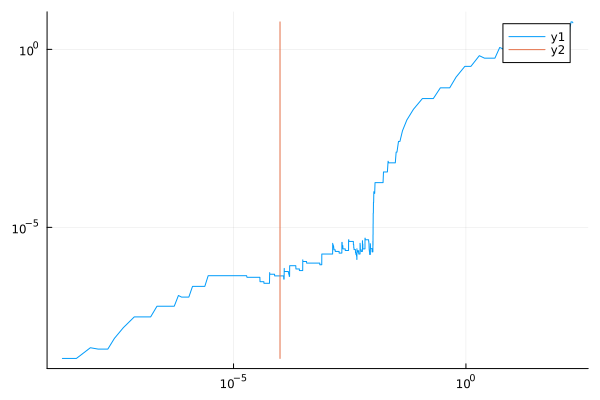

In [101]:
plot(
    sol.t[2:end],
    dt,
    xscale = :log10,
    yscale = :log10
)

plot!(
    [τ, τ],
    [minimum(dt), maximum(dt)]
)

In [84]:
dt = sol.t[2:end] .- sol.t[1:end-1]

4983-element Vector{Float64}:
 2.0779183388689445e-9
 2.0779183388689445e-9
 4.155836677737889e-9
 3.810443200526431e-9
 3.810443200526432e-9
 3.810443200526432e-9
 7.620886401052861e-9
 1.5241772802105723e-8
 3.048354560421146e-8
 3.048354560421146e-8
 3.048354560421146e-8
 3.048354560421146e-8
 6.096709120842292e-8
 ⋮
 2.2460580232066434
 2.2460580232066434
 2.2460580232066434
 2.2460580232066434
 2.2460580232066434
 2.2460580232066434
 4.492116046413315
 4.492116046413315
 5.899258588817247
 5.899258588817247
 5.899258588817247
 5.569287755391002

In [111]:
t = 1e-3

U = sol(t)

sol_v = U[v_global]
sol_ρ = U[rho_global]
sol_ρ_s = U[rho_s_global]

discrete_x = range(0.0, 1.0, length=size(sol_ρ, 1))

ρmax = maximum(sol_ρ)
ρmin = minimum(sol_ρ)

rhosmin = minimum(sol_ρ_s)
rhosmax = maximum(sol_ρ_s)

# density plot
p_density = plot(
    discrete_x,
    sol_ρ,
    label="gas density",
    color=:blue,
    linewidth=2,
    xlabel="x",
    ylabel="gas density [kg/m³]",
    ylims=(0, ρmax),
    title="t = $(round(t*1000, digits=3)) ms",
    legend=:topleft,
    yguidefontcolor=:blue,
    ytickfontcolor=:blue
)

p_density_right = twinx(p_density)

plot!(
    p_density_right,
    discrete_x,
    sol_ρ_s,
    label="solid density",
    color=:red,
    linewidth=2,
    ylabel="solid density [kg/m³]",
    ylims=(rhosmin, rhosmax),
    legend=:topright,
    yguidefontcolor=:red,
    ytickfontcolor=:red
)

savefig(p_density, "g. realistic values\\model4_density_snapshot.png")

"c:\\Users\\noudh\\uni\\MEP\\4. fem model two\\g. realistic values\\model4_density_snapshot.png"

In [112]:
p_velocity = plot(
    discrete_x,
    sol_v,
    label="velocity",
    linewidth=2,
    xlabel="x",
    ylabel="velocity [m/s]",
    title="t = $(round(t*1000, digits=3)) ms",
    legend=:topright
)

savefig(p_velocity, "g. realistic values\\model4_velocity_snapshot.png")

"c:\\Users\\noudh\\uni\\MEP\\4. fem model two\\g. realistic values\\model4_velocity_snapshot.png"

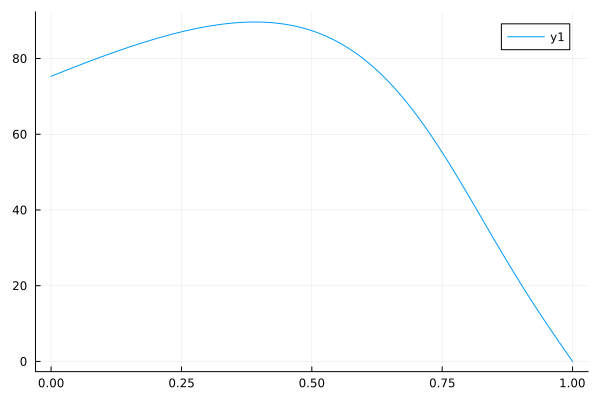

In [106]:
plot(discrete_x, sol_v)

In [32]:
# double gif plot
foldername = name

U = Array(sol)

sol_v = U[v_global, :]
sol_ρ = U[rho_global, :]
sol_ρ_s = U[rho_s_global, :]

discrete_x = range(0.0, 1.0, length=size(sol_ρ, 1))
discrete_t = sol.t #range(dt_save, step=dt_save, length=size(sol_ρ, 2))

ρmax = maximum(sol_ρ)
ρmin = minimum(sol_ρ)

rhosmin = minimum(sol_ρ_s)
rhosmax = maximum(sol_ρ_s)

# ptot = 1/2 rho v^2 + R T rho
ptot = 0.5 * sol_ρ .* sol_v.^2 .+ R * T * sol_ρ

ptotmin = minimum(ptot)
ptotmax = maximum(ptot)

vmax = maximum(sol_v)
vmin = minimum(sol_v)

anim = @animate for k in 1:size(sol_ρ, 2)

    p1 = plot(
        discrete_x,
        sol_ρ[:, k],
        label="density gas",
        color=:blue,
        xlabel="x",
        ylabel="density [kg/m3]",
        ylims=(0, ρmax),
        title="t = $(round(discrete_t[k]*1000, digits=3))ms",
        legend=:topright
    )

    p2  = plot(
        discrete_x,
        sol_ρ_s[:, k],
        label="density solid",
        color=:red,
        ylims=(rhosmin, rhosmax),
        xlabel="x",
        ylabel="density [kg/m3]",
        legend=:topright
    )

    p3 = plot(
        discrete_x,
        ptot[:, k],
        label="total pressure",
        color=:orange,
        ylims=(ptotmin, ptotmax),
        xlabel="x",
        ylabel="total pressure [Pa]",
        legend=:topright
    )

    p4 = plot(
        discrete_x,
        sol_v[:, k],
        label="velocity",
        color=:green,
        xlabel="x",
        ylabel="velocity [m/s]",
        ylims=(vmin, vmax),
        legend=:topright
    )

    plot(p1, p2, p3, p4, layout=(2,2), size=(800,600))
end

Animation("C:\\Users\\noudh\\AppData\\Local\\Temp\\jl_UDKVTM", ["000001.png", "000002.png", "000003.png", "000004.png", "000005.png", "000006.png", "000007.png", "000008.png", "000009.png", "000010.png"  …  "000992.png", "000993.png", "000994.png", "000995.png", "000996.png", "000997.png", "000998.png", "000999.png", "001000.png", "001001.png"])

[ Info: Saved animation to c:\Users\noudh\uni\MEP\4. fem model two\g. realistic values\aa2.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\4. fem model two\\g. realistic values\\aa2.gif")
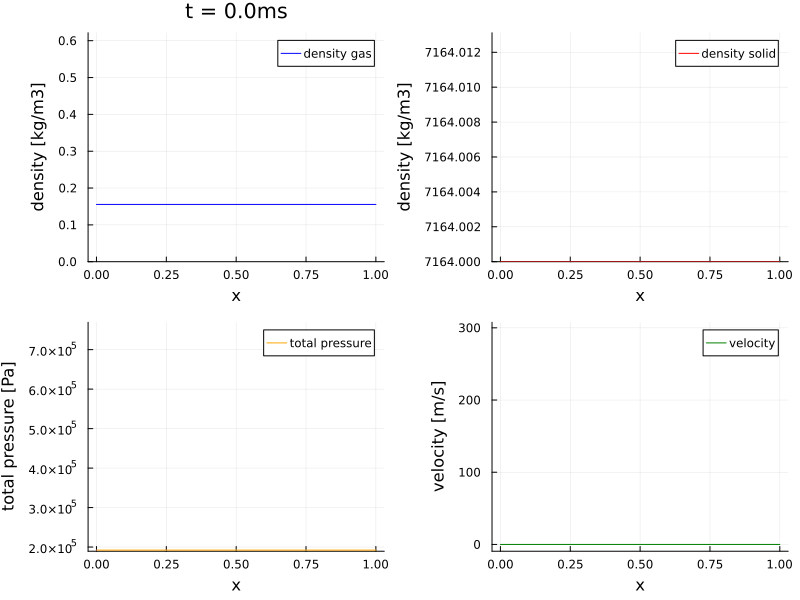

In [33]:
gif(anim, joinpath(foldername, "aa2.gif"), fps=30)

[ Info: Saved animation to c:\Users\noudh\uni\MEP\4. fem model two\g. realistic values\real_values_opening_vat.gif


Plots.AnimatedGif("c:\\Users\\noudh\\uni\\MEP\\4. fem model two\\g. realistic values\\real_values_opening_vat.gif")
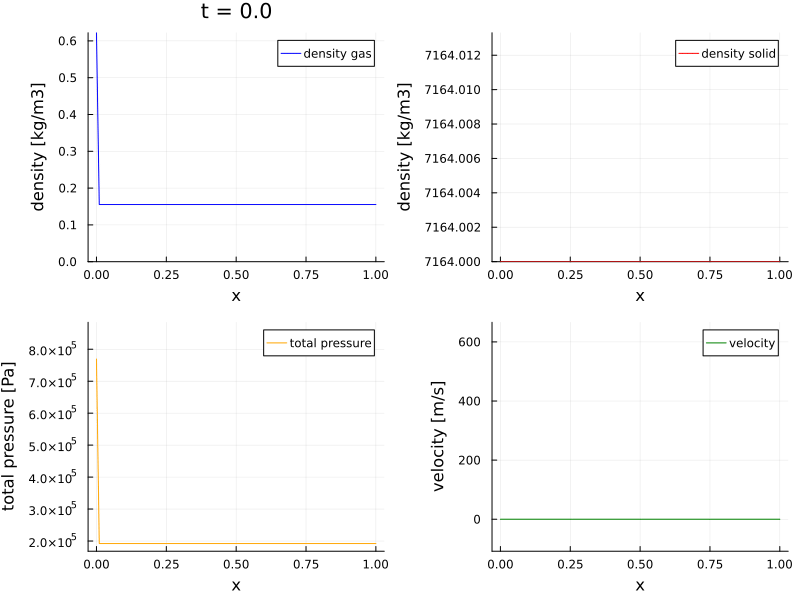

In [ ]:
gif(anim, joinpath(foldername, "real_values_long_term.gif"), fps=10)

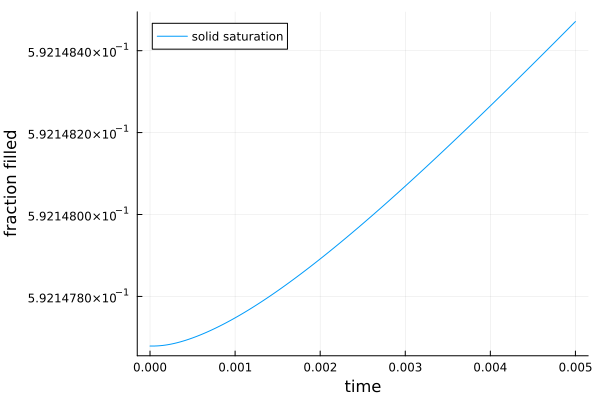

In [156]:
# We calculate the FE integration weights for rho_s.
#
# The mass matrix is:
#
#     M_ij = ∫ phi_i * phi_j dx
#
# Multiplying it by a vector of ones gives:
#
#     b_i = Σ_j M_ij = ∫ phi_i dx
#
# which is the correct FE weight for integrating the solution:
#
#     ∫ rho_s dx ≈ b ⋅ rho_s
#
# This automatically handles the dx/2 boundary contributions
# for P1 elements and also works for nonuniform meshes.
M_rho_s = ML[rho_s_global, rho_s_global]
mass_weights_rho_s = M_rho_s * ones(length(rho_s_global))


# Calculate total absorbed amount at every saved timestep
absorbed_mass = zeros(size(sol_ρ_s, 2))

for k in axes(sol_ρ_s, 2)

    # FE approximation of:
    #
    #     M_s(t) = ∫ rho_s(x,t) dx
    #
    absorbed_mass[k] = dot(mass_weights_rho_s, sol_ρ_s[:, k])

end


# Maximum possible absorbed mass:
#
#     M_sat = ∫ rho_sat dx = rho_sat * L
#
# Here L = 1, but keeping the formula general.

maximum_mass = ρ_sat * 1.0


# Fraction of solid capacity filled
fill_fraction = absorbed_mass ./ maximum_mass


# Plot filling fraction versus time
plot(
    discrete_t,
    fill_fraction,
    xlabel = "time",
    ylabel = "fraction filled",
    label = "solid saturation",
)

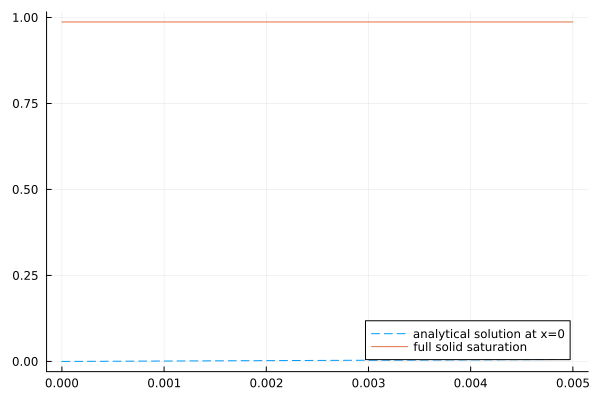

In [160]:
plot(
    sol.t,
    sol_ρ_s[1, :],
    xlabel = "time (s)",
    ylabel = "saturation",
    label = "saturation at x=0",
    legend=:bottomright
)
k = log(2)/(1-ϵ)
plot!(
    sol.t,
    1.0 .- 1 .* exp.(-k.*sol.t),
    label = "analytical solution at x=0",
    linestyle = :dash
)

plot!(
    sol.t,
    fill_fraction/(1-ϵ),
    # xlabel = "time",
    # ylabel = "fraction filled",
    label = "full solid saturation"
    )

plot!(
    sol.t,
    sol_ρ_s[end, :],
    # xlabel = "time",
    # ylabel = "solid density [kg/m^3]",
    label = "saturation at x=L"
)


In [ ]:
savefig(joinpath(foldername, "fill_fraction total pressure.png"))

# OLD

In [135]:
function assemble_mass!(
        M::SparseMatrixCSC,
        u::Vector{Float64},
        params::RHSparams
    )

    copyto!(M, params.ML)  # set M equal to the linear part of the mass matrix, which is constant in time

    # now for the non-linear part:

    # number of basis functions per field
    n_basefuncs_v  = getnbasefunctions(params.cellvalues_v)
    n_basefuncs_rhog  = getnbasefunctions(params.cellvalues_rhog)
    
    first_cell = first(CellIterator(params.dh))
    ndofs_cell = length(celldofs(first_cell))
    Me = zeros(ndofs_cell, ndofs_cell)

    assembler = start_assemble(M; fillzero=false) # do not fill zero since we already have the linear part in it!
    v_dofs = dof_range(params.dh, :v)
    rhog_dofs = dof_range(params.dh, :rho)

    # loop over all cells
    for cell in CellIterator(params.dh)    
        # get local dofs of this cell for v
        cell_dofs = celldofs(cell)
        rhog_local = u[cell_dofs[rhog_dofs]]

        fill!(Me,0)

        Ferrite.reinit!(params.cellvalues_v, cell)
        Ferrite.reinit!(params.cellvalues_rhog, cell) 

        for q in 1:getnquadpoints(params.cellvalues_v)
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:n_basefuncs_rhog
            )

            dx = getdetJdV(params.cellvalues_v, q)

            for k in 1:n_basefuncs_v
                psi_k = shape_value(params.cellvalues_v, q, k)
                for i in 1:n_basefuncs_v
                    psi_i = shape_value(params.cellvalues_v, q, i)
                    Me[v_dofs[k], v_dofs[i]] += rhog_q*psi_k*psi_i*dx
                end
            end
        end
        assemble!(assembler, cell_dofs, Me)
    end
    return M
end

assemble_mass! (generic function with 1 method)

In [137]:
function assemble_rhs!(
    N::Vector{Float64},
    u::Vector{Float64},
    params::RHSparams
)

    N .= params.rhsL * u # This line computes the linear part of the right-hand side by multiplying the linear part of the right-hand side matrix (params.rhsL) with the solution vector (u). The result is stored in N, which represents the complete right-hand side vector for the system of equations.

    # now for the non-linear part:
    rhog_dofs = dof_range(params.dh, :rho)
    rhos_dofs = dof_range(params.dh, :rho_s)
    v_dofs    = dof_range(params.dh, :v)

    for cell in CellIterator(params.dh)

        cell_dofs = celldofs(cell)

        rhog_local = view(u, cell_dofs[rhog_dofs])
        rhos_local = view(u, cell_dofs[rhos_dofs])
        v_local    = view(u, cell_dofs[v_dofs])

        Ferrite.reinit!(params.cellvalues_rhog, cell)
        Ferrite.reinit!(params.cellvalues_rhos, cell)
        Ferrite.reinit!(params.cellvalues_v, cell)

        for q in 1:getnquadpoints(params.cellvalues_rhog)

            dx = getdetJdV(params.cellvalues_rhog,q)

            # calculate the values of rhog, rhos, v, and ∂v at the quadrature point
            rhog_q = sum(
                rhog_local[j] *
                shape_value(params.cellvalues_rhog,q,j)
                for j in 1:length(rhog_local)
            )

            rhos_q = sum(
                rhos_local[j] *
                shape_value(params.cellvalues_rhos,q,j)
                for j in 1:length(rhos_local)
            )

            v_q = sum(
                v_local[j] *
                shape_value(params.cellvalues_v,q,j)
                for j in 1:length(v_local)
            )          
            dv_q = sum(
                v_local[j] *
                shape_gradient(params.cellvalues_v,q,j)[1]
                for j in 1:length(v_local)
            )

            # Convection term of rhog                               
            for k in 1:length(rhog_local)
                dψ = shape_gradient(params.cellvalues_rhog,q,k)
                N[cell_dofs[rhog_dofs[k]]] += dψ[1] * v_q * rhog_q * dx
            end

            # Convection term of v
            for k in 1:length(v_local)
                ψ = shape_value(params.cellvalues_v,q,k)
                N[cell_dofs[v_dofs[k]]] += ψ * rhog_q * v_q *dv_q * dx            
            end

            # dot m =       A  *log(       R*       T*rhog  /       p_eqa)*(       rho_sat-rhos)
            mdot_q = params.A_a*log(params.R*params.T*rhog_q/params.p_eqa)*(params.rho_sat-rhos_q)
            for i in 1:length(rhog_local)
                ψ = shape_value(params.cellvalues_rhog,q,i)
                N[cell_dofs[rhog_dofs[i]]] -= ψ*mdot_q*dx
            end

            for i in 1:length(rhos_local)
                ψ = shape_value(params.cellvalues_rhos,q,i)
                N[cell_dofs[rhos_dofs[i]]] += ψ*mdot_q*dx
            end
        end
    end
    return N
end

assemble_rhs! (generic function with 1 method)